In [44]:
import os
from PIL import Image
import numpy as np

colors = np.array([[67, 99, 216], [255, 225, 25], [60, 180, 75], [245, 80, 49], [145, 30, 180]])
image_root = 'data/hypernerf/split-cookie/rgb/2x'
image_name = '000192'
mask_root = f'data/hypernerf/split-cookie/segmentations/{image_name}'
mask_names = os.listdir(mask_root)
mask_names.sort()

image_np = np.array(Image.open(f'{image_root}/{image_name}.png'))
total_mask = []
for idx, mask_name in enumerate(mask_names):
    mask = np.array(Image.open(f'{mask_root}/{mask_name}')) > 0
    image_np[mask, :] = image_np[mask, :] * 0.5 + colors[idx] * 0.5
    total_mask.append(mask)
total_mask = np.stack(total_mask).sum(0) > 0
image_np[~total_mask, :] //= 3

Image.fromarray(image_np.astype(np.uint8)).save('../hypernerf_results/split-cookie/gt_000192.jpg')

In [14]:
import os
from PIL import Image
import numpy as np

colors = np.array([[67, 99, 216], [255, 225, 25], [60, 180, 75], [245, 80, 49], [145, 30, 180]])
roots = ['output/americano_1/test/ours_None',
        'output/chickchicken_1/test/ours_None',
        'output/slice-banana_1/test/ours_None',
        'output/split-cookie_1/test/ours_None',
        'output/torchocolate_1/test/ours_None',
]

image_names = ['000091','000050','000244','000192','000331']
for i in range(0, 5):
    root = roots[i]
    image_name = image_names[i]
    scene_name = root.split('/')[1].split('_')[0]

    image_root = f'{root}/{image_name}/renders/rendering.jpg'
    mask_root = f'{root}/{image_name}/mask'
    mask_names = os.listdir(mask_root)
    mask_names.sort()

    image_np = np.array(Image.open(f'{image_root}'))
    # image_np = np.array(Image.open('data/hypernerf/split-cookie/rgb/2x/000030.png'))
    total_mask = []
    for idx, mask_name in enumerate(mask_names):
        mask = (np.array(Image.open(f'{mask_root}/{mask_name}')) // 255) > 0
        # print(mask.max())
        image_np[mask, :] = colors[idx]
        total_mask.append(mask)
    total_mask = np.stack(total_mask).sum(0) > 0
    image_np[~total_mask, :] //= 3

    Image.fromarray(image_np.astype(np.uint8)).save(f'../hypernerf_results/{scene_name}/lansplat_{image_name}.jpg')

In [17]:
import os
from PIL import Image
import numpy as np

colors = np.array([[67, 99, 216], [255, 225, 25], [60, 180, 75], [245, 80, 49], [145, 30, 180]])
roots = ['output/asnovelview_1/test/ours_None',
        'output/basinnovelview_1/test/ours_None',
        'output/bellnovelview_1/test/ours_None',
        'output/cupnovelview_1/test/ours_None',
        'output/sievenovelview_1/test/ours_None'
]
image_names = ['000151_right','000091_right','000271_right','000151_right','000091_right']
scene_names = ['as','basin','bell','cup','sieve']
for i in range(0,5):
    root = roots[i]
    image_name = image_names[i]
    scene_name = scene_names[i]
    
    image_root = f'{root}/{image_name}/renders/rendering.jpg'
    mask_root = f'{root}/{image_name}/mask'
    mask_names = os.listdir(mask_root)
    mask_names.sort()

    image_np = np.array(Image.open(f'{image_root}'))
    # image_np = np.array(Image.open('data/hypernerf/split-cookie/rgb/2x/000030.png'))
    total_mask = []
    for idx, mask_name in enumerate(mask_names):
        mask = (np.array(Image.open(f'{mask_root}/{mask_name}')) // 255) > 0
        # print(mask.max())
        image_np[mask, :] = colors[idx]
        total_mask.append(mask)
    total_mask = np.stack(total_mask).sum(0) > 0
    image_np[~total_mask, :] //= 3

    Image.fromarray(image_np.astype(np.uint8)).save(f'../nerf_ds_results/{scene_name}/lansplat_{image_name}.jpg')

In [35]:
np.array(Image.open('output/hypernerf/split-cookie/test/save_contrastive_loss_d_semantic_feature_reset_scale_step_1/000030/mask/cutting board.png'))

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [255, 255, 255, ...,   0,   0,   0],
       [255, 255, 255, ...,   0,   0,   0],
       [255, 255, 255, ...,   0,   0,   0]], dtype=uint8)

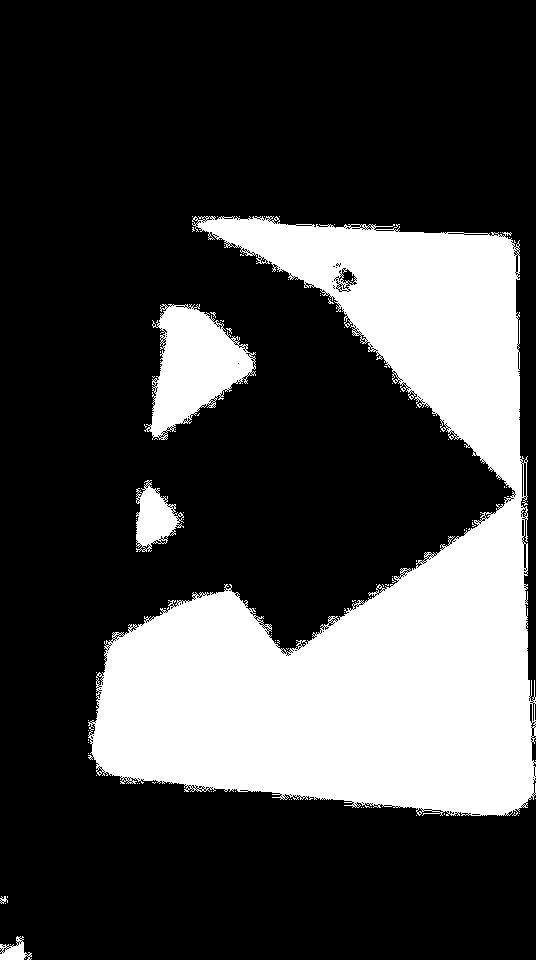

In [21]:
Image.fromarray(((np.array(Image.open('output/hypernerf/split-cookie/test/save_contrastive_loss_d_semantic_feature_reset_scale_step_1/000030/mask/cutting board.jpg')) > 0) * 255).astype(np.uint8))